# 02 - Pandas 数据处理与可视化

**目标**: 掌握 Pandas 数据处理与 Matplotlib/Seaborn 可视化

**预计时间**: 2-3 小时

**前置知识**: NumPy 基础 (01_numpy_basics.ipynb)

---

## 1. 导入库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置显示选项
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置样式
sns.set_style('whitegrid')

print(f"Pandas 版本: {pd.__version__}")
print(f"NumPy 版本: {np.__version__}")

Pandas 版本: 3.0.5
NumPy 版本: 2.4.4


## 2. Pandas 核心数据结构

In [2]:
# Series - 一维带标签数组
s = pd.Series([1, 3, 5, np.nan, 6, 8])
print("Series 示例:")
print(s)
print(f"\n数据类型: {s.dtype}")
print(f"索引: {s.index.tolist()}")

Series 示例:
0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

数据类型: float64
索引: [0, 1, 2, 3, 4, 5]


In [3]:
# DataFrame - 二维表格数据结构
dates = pd.date_range('20230101', periods=6)
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list('ABCD'))

print("DataFrame 示例:")
print(df)
print(f"\n形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
print(f"索引: {df.index.tolist()[:3]}...")  # 只显示前3个

DataFrame 示例:
                   A         B         C         D
2023-01-01  2.678113  0.886955  1.001894  1.102071
2023-01-02  0.286392 -0.158996  0.868743 -1.439394
2023-01-03 -0.515965 -0.074363  0.099441  1.862426
2023-01-04 -0.155263  1.183688  1.209684 -0.624719
2023-01-05 -0.562131 -0.292219 -2.403327  0.371551
2023-01-06 -0.327552 -0.347814  1.290188  0.088297

形状: (6, 4)
列名: ['A', 'B', 'C', 'D']
索引: [Timestamp('2023-01-01 00:00:00'), Timestamp('2023-01-02 00:00:00'), Timestamp('2023-01-03 00:00:00')]...


## 3. 创建 DataFrame 的多种方式

In [4]:
# 方式1: 从字典创建
df_dict = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Charlie', 'David'],
    'age': [25, 30, 35, 28],
    'city': ['New York', 'London', 'Paris', 'Tokyo'],
    'salary': [50000, 60000, 75000, 55000]
})
print("从字典创建:")
print(df_dict)
print(f"\n数据类型:\n{df_dict.dtypes}")

从字典创建:
      name  age      city  salary
0    Alice   25  New York   50000
1      Bob   30    London   60000
2  Charlie   35     Paris   75000
3    David   28     Tokyo   55000

数据类型:
name        str
age       int64
city        str
salary    int64
dtype: object


In [5]:
# 方式2: 从列表的列表创建
df_list = pd.DataFrame([
    ['Alice', 25, 'New York'],
    ['Bob', 30, 'London'],
    ['Charlie', 35, 'Paris']
], columns=['name', 'age', 'city'])

print("从列表创建:")
print(df_list)

从列表创建:
      name  age      city
0    Alice   25  New York
1      Bob   30    London
2  Charlie   35     Paris


In [6]:
# 方式3: 从 NumPy 数组创建
df_np = pd.DataFrame(
    np.random.randint(0, 100, size=(5, 3)),
    columns=['Math', 'English', 'Science']
)
df_np['student'] = ['S1', 'S2', 'S3', 'S4', 'S5']

print("从 NumPy 数组创建:")
print(df_np)

从 NumPy 数组创建:
   Math  English  Science student
0    20       33       28      S1
1    40       93       61      S2
2    34       54       43      S3
3    46       56        9      S4
4    16        8        8      S5


## 4. 数据查看与选择

In [7]:
# 使用之前创建的员工数据
df = df_dict.copy()
print("原始数据:")
print(df)

# 查看前几行/后几行
print("\n前2行:")
print(df.head(2))

print("\n后2行:")
print(df.tail(2))

# 查看基本信息
print("\n数据信息:")
print(df.info())

原始数据:
      name  age      city  salary
0    Alice   25  New York   50000
1      Bob   30    London   60000
2  Charlie   35     Paris   75000
3    David   28     Tokyo   55000

前2行:
    name  age      city  salary
0  Alice   25  New York   50000
1    Bob   30    London   60000

后2行:
      name  age   city  salary
2  Charlie   35  Paris   75000
3    David   28  Tokyo   55000

数据信息:
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    4 non-null      str  
 1   age     4 non-null      int64
 2   city    4 non-null      str  
 3   salary  4 non-null      int64
dtypes: int64(2), str(2)
memory usage: 260.0 bytes
None


In [8]:
# 选择列
print("选择单列 (Series):")
print(df['name'])

print("\n选择多列 (DataFrame):")
print(df[['name', 'age']])

# 选择行（通过索引）
print("\n第一行 (iloc):")
print(df.iloc[0])

print("\n第1-3行:")
print(df.iloc[0:3])

选择单列 (Series):
0      Alice
1        Bob
2    Charlie
3      David
Name: name, dtype: str

选择多列 (DataFrame):
      name  age
0    Alice   25
1      Bob   30
2  Charlie   35
3    David   28

第一行 (iloc):
name         Alice
age             25
city      New York
salary       50000
Name: 0, dtype: object

第1-3行:
      name  age      city  salary
0    Alice   25  New York   50000
1      Bob   30    London   60000
2  Charlie   35     Paris   75000


In [9]:
# 条件筛选
print("年龄大于28岁的员工:")
print(df[df['age'] > 28])

print("\n薪资在55000-65000之间的员工:")
print(df[(df['salary'] >= 55000) & (df['salary'] <= 65000)])

print("\n住在 London 或 Paris 的员工:")
print(df[df['city'].isin(['London', 'Paris'])])

年龄大于28岁的员工:
      name  age    city  salary
1      Bob   30  London   60000
2  Charlie   35   Paris   75000

薪资在55000-65000之间的员工:
    name  age    city  salary
1    Bob   30  London   60000
3  David   28   Tokyo   55000

住在 London 或 Paris 的员工:
      name  age    city  salary
1      Bob   30  London   60000
2  Charlie   35   Paris   75000


## 5. 数据清洗

In [10]:
# 创建包含缺失值的数据
df_dirty = pd.DataFrame({
    'A': [1, 2, np.nan, 4, 5],
    'B': [10, np.nan, np.nan, 40, 50],
    'C': [100, 200, 300, np.nan, 500]
})

print("包含缺失值的数据:")
print(df_dirty)

# 检查缺失值
print("\n缺失值统计:")
print(df_dirty.isnull().sum())

print("\n缺失值比例:")
print(df_dirty.isnull().mean())

包含缺失值的数据:
     A     B      C
0  1.0  10.0  100.0
1  2.0   NaN  200.0
2  NaN   NaN  300.0
3  4.0  40.0    NaN
4  5.0  50.0  500.0

缺失值统计:
A    1
B    2
C    1
dtype: int64

缺失值比例:
A    0.2
B    0.4
C    0.2
dtype: float64


In [11]:
# 处理缺失值
print("删除包含缺失值的行:")
print(df_dirty.dropna())

print("\n用均值填充:")
print(df_dirty.fillna(df_dirty.mean()))

print("\n用特定值填充:")
print(df_dirty.fillna({'A': 0, 'B': 999, 'C': -1}))

删除包含缺失值的行:
     A     B      C
0  1.0  10.0  100.0
4  5.0  50.0  500.0

用均值填充:
     A          B      C
0  1.0  10.000000  100.0
1  2.0  33.333333  200.0
2  3.0  33.333333  300.0
3  4.0  40.000000  275.0
4  5.0  50.000000  500.0

用特定值填充:
     A      B      C
0  1.0   10.0  100.0
1  2.0  999.0  200.0
2  0.0  999.0  300.0
3  4.0   40.0   -1.0
4  5.0   50.0  500.0


In [12]:
# 处理重复值
df_dup = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Alice', 'Charlie', 'Bob'],
    'score': [85, 90, 85, 88, 92]
})

print("包含重复的数据:")
print(df_dup)

print("\n检查重复:")
print(df_dup.duplicated())

print("\n删除重复 (保留第一个):")
print(df_dup.drop_duplicates())

print("\n删除重复 (保留最后一个):")
print(df_dup.drop_duplicates(keep='last'))

包含重复的数据:
      name  score
0    Alice     85
1      Bob     90
2    Alice     85
3  Charlie     88
4      Bob     92

检查重复:
0    False
1    False
2     True
3    False
4    False
dtype: bool

删除重复 (保留第一个):
      name  score
0    Alice     85
1      Bob     90
3  Charlie     88
4      Bob     92

删除重复 (保留最后一个):
      name  score
1      Bob     90
2    Alice     85
3  Charlie     88
4      Bob     92


## 6. 数据统计与分析

In [13]:
# 使用学生成绩数据
np.random.seed(42)
df_scores = pd.DataFrame({
    'Math': np.random.normal(75, 10, 100),
    'English': np.random.normal(80, 8, 100),
    'Science': np.random.normal(78, 12, 100)
})

print("成绩统计摘要:")
print(df_scores.describe())

print("\n各科均值:")
print(df_scores.mean())

print("\n各科标准差:")
print(df_scores.std())

成绩统计摘要:
             Math     English     Science
count  100.000000  100.000000  100.000000
mean    73.961535   80.178437   78.778755
std      9.081684    7.629352   13.011395
min     48.802549   64.649830   39.104792
25%     68.990943   73.554716   70.134678
50%     73.730437   80.672857   79.172349
75%     79.059521   84.305364   86.453249
max     93.522782  101.761353  124.232778

各科均值:
Math       73.961535
English    80.178437
Science    78.778755
dtype: float64

各科标准差:
Math        9.081684
English     7.629352
Science    13.011395
dtype: float64


In [14]:
# 分组统计
df_sales = pd.DataFrame({
    'Region': ['North', 'South', 'North', 'East', 'South', 'East', 'North'],
    'Product': ['A', 'A', 'B', 'A', 'B', 'B', 'A'],
    'Sales': [100, 150, 200, 120, 180, 220, 130]
})

print("销售数据:")
print(df_sales)

print("\n按地区分组统计:")
print(df_sales.groupby('Region')['Sales'].agg(['sum', 'mean', 'count']))

print("\n按地区和产品分组:")
print(df_sales.groupby(['Region', 'Product'])['Sales'].sum())

销售数据:
  Region Product  Sales
0  North       A    100
1  South       A    150
2  North       B    200
3   East       A    120
4  South       B    180
5   East       B    220
6  North       A    130

按地区分组统计:
        sum        mean  count
Region                        
East    340  170.000000      2
North   430  143.333333      3
South   330  165.000000      2

按地区和产品分组:
Region  Product
East    A          120
        B          220
North   A          230
        B          200
South   A          150
        B          180
Name: Sales, dtype: int64


## 7. Matplotlib 基础可视化

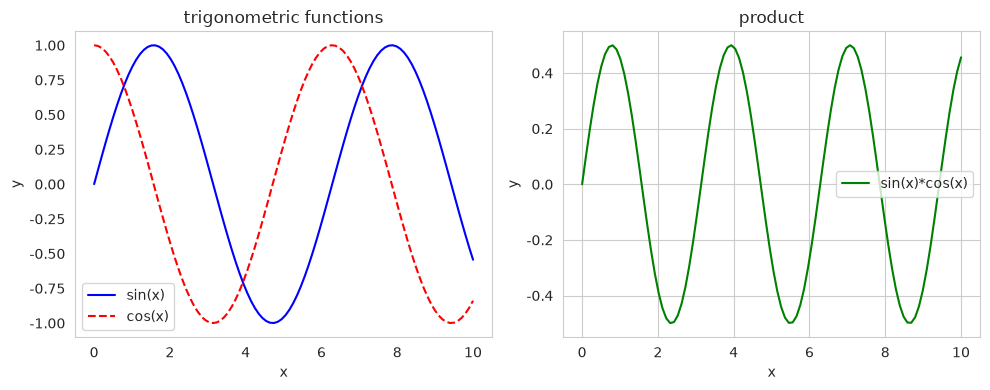

In [15]:
# 折线图
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x, y1, label='sin(x)', color='blue')
plt.plot(x, y2, label='cos(x)', color='red', linestyle='--')
plt.title('trigonometric functions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(False)

plt.subplot(1, 2, 2)
plt.plot(x, y1 * y2, label='sin(x)*cos(x)', color='green')
plt.title('product')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

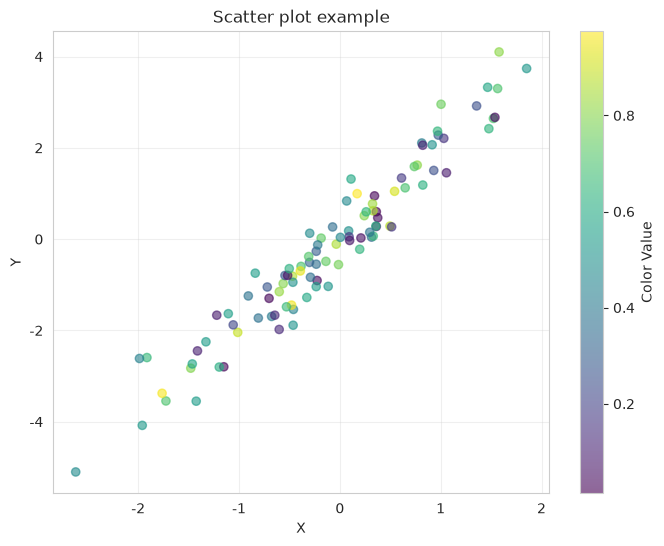

In [16]:
# 散点图
np.random.seed(42)
x = np.random.randn(100)
y = 2 * x + np.random.randn(100) * 0.5
colors = np.random.rand(100)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=colors, alpha=0.6, cmap='viridis')
plt.colorbar(label='Color Value')
plt.title('Scatter plot example')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_2564/955774017.py:18: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2564/955774017.py:18: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2564/955774017.py:18: UserWarning: Glyph 26609 (\N{CJK UNIFIED IDEOGRAPH-67F1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2564/955774017.py:18: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2564/955774017.py:18: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2564/955774017.py:18: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2564/955774017.py:18: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missi

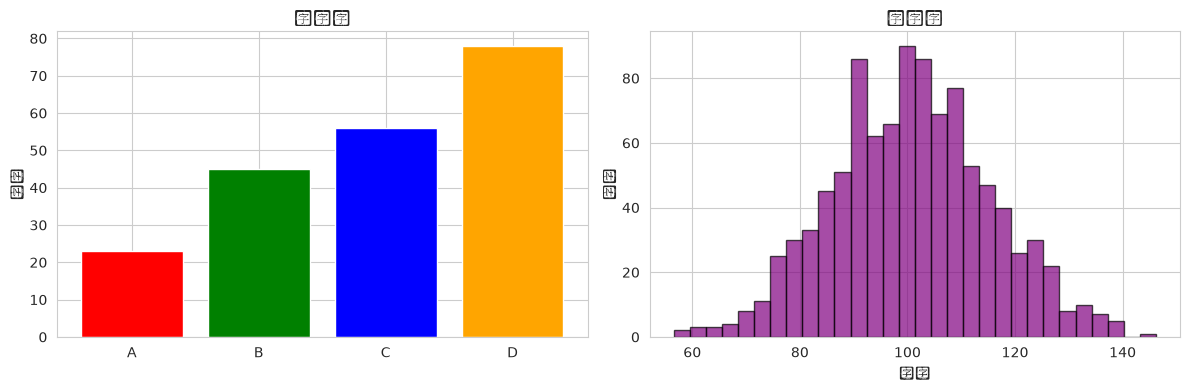

In [17]:
# 柱状图和直方图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 柱状图
categories = ['A', 'B', 'C', 'D']
values = [23, 45, 56, 78]
axes[0].bar(categories, values, color=['red', 'green', 'blue', 'orange'])
axes[0].set_title('柱状图')
axes[0].set_ylabel('数值')

# 直方图
data = np.random.normal(100, 15, 1000)
axes[1].hist(data, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1].set_title('直方图')
axes[1].set_xlabel('数值')
axes[1].set_ylabel('频数')

plt.tight_layout()
plt.show()

## 8. Seaborn 高级可视化

In [18]:
# 使用 Seaborn 内置数据集
tips = sns.load_dataset('tips')
print("Tips 数据集:")
print(tips.head())
print(f"\n形状: {tips.shape}")

Tips 数据集:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

形状: (244, 7)


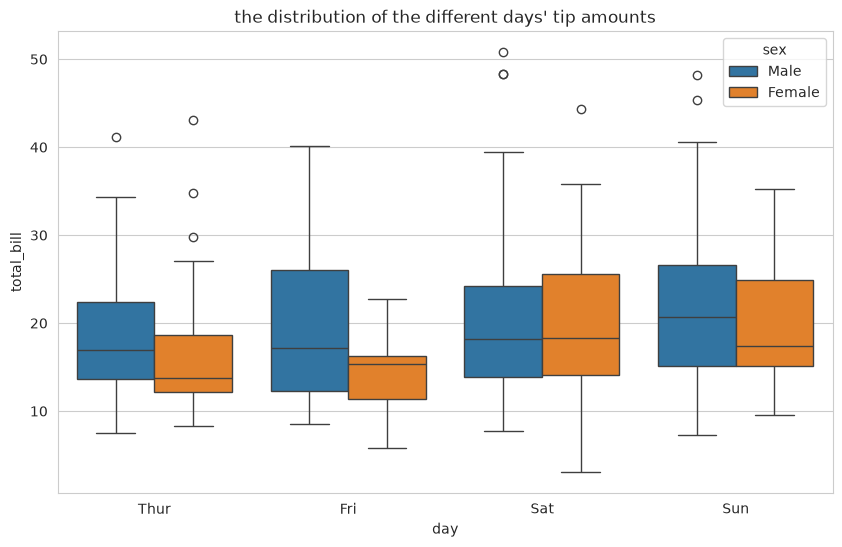

In [24]:
# 箱线图
plt.figure(figsize=(10, 6))
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex')
plt.title("the distribution of the different days' tip amounts") # 不同日期的小费金额分布
plt.show()

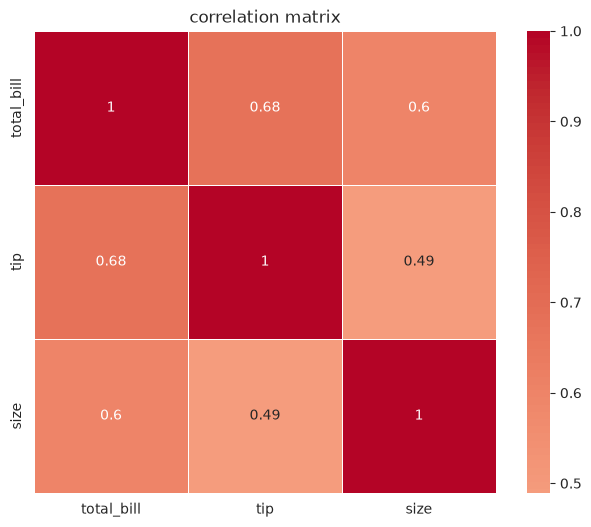

In [25]:
# 热力图 - 相关性矩阵
plt.figure(figsize=(8, 6))
corr = tips[['total_bill', 'tip', 'size']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title("correlation matrix") # 相关性热力图 
plt.show()

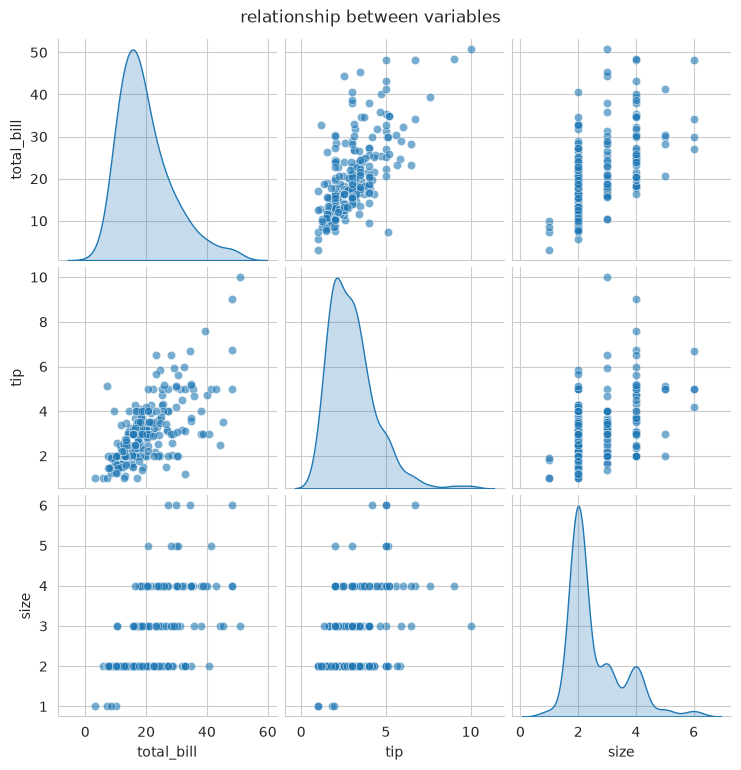

In [26]:
#  pairplot - 多变量关系
sns.pairplot(tips[['total_bill', 'tip', 'size']],
             diag_kind='kde',
             plot_kws={'alpha': 0.6})
plt.suptitle('relationship between variables', y=1.02) # 变量关系图
plt.show()

## 9. 综合练习：鸢尾花数据集分析

In [35]:
# 加载鸢尾花数据集
from sklearn.datasets import load_iris

iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("鸢尾花数据集:")
print(df_iris.head(10))
print(f"\n形状: {df_iris.shape}")
print(f"\n类别分布:\n{df_iris['species'].value_counts()}")



鸢尾花数据集:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  
6  setosa  
7  setosa  
8  setosa  
9 

各特征的统计摘要:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
species                       
setosa                 0.246  
versicolor             1.326  
virginica              2.026  


/home/r7_luka/miniconda3/envs/bot-lab/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 33457 (\N{CJK UNIFIED IDEOGRAPH-82B1}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/r7_luka/miniconda3/envs/bot-lab/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 33852 (\N{CJK UNIFIED IDEOGRAPH-843C}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/r7_luka/miniconda3/envs/bot-lab/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/r7_luka/miniconda3/envs/bot-lab/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/r7_luka/miniconda3/envs/bot-lab/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


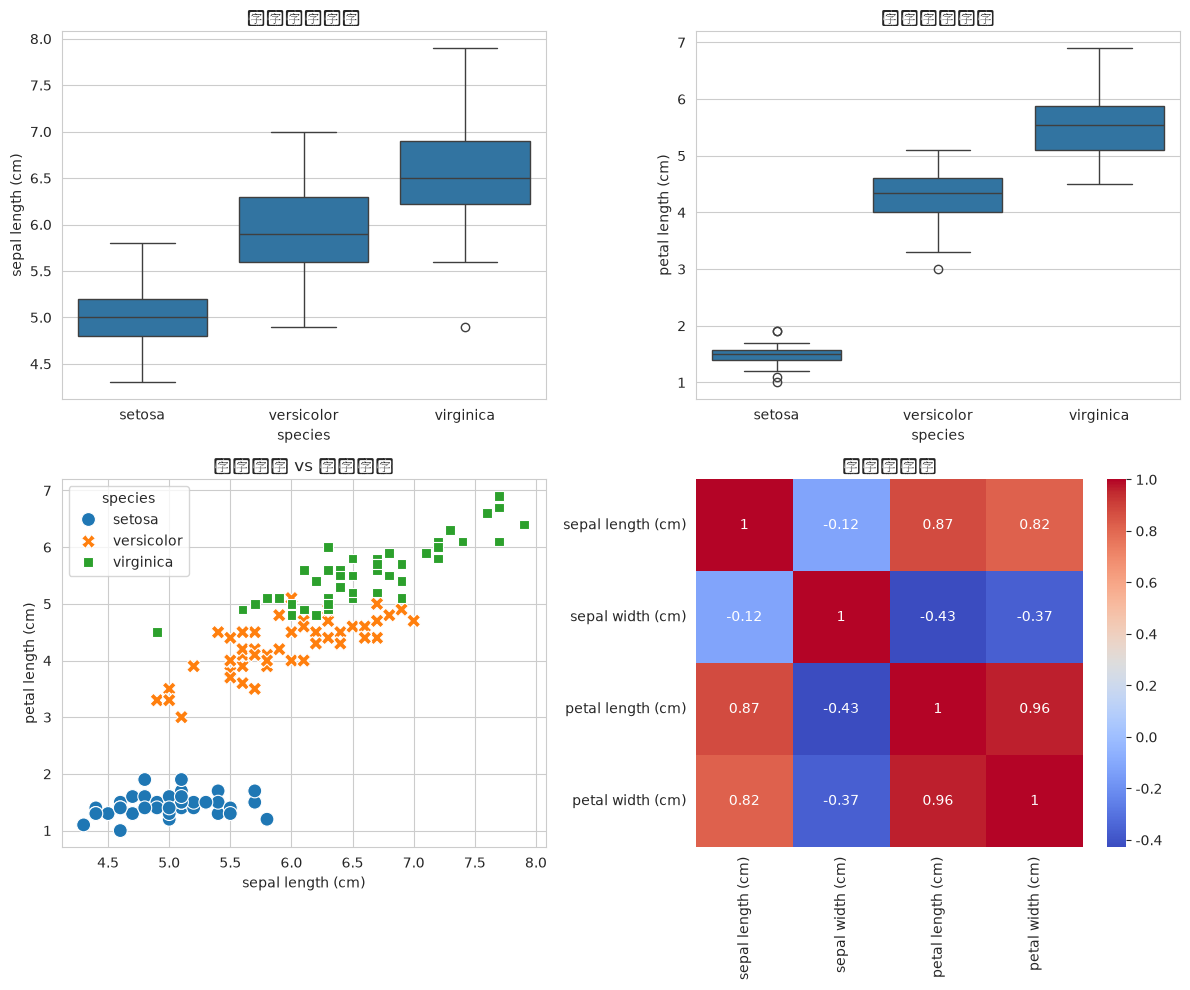

In [ ]:
# 统计分析
print("各特征的统计摘要:")
print(df_iris.groupby('species').mean())

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 花萼长度分布
sns.boxplot(data=df_iris, x='species', y='sepal length (cm)', ax=axes[0, 0])
axes[0, 0].set_title('sepal length distribution') # 花萼长度分布

# 花瓣长度分布
sns.boxplot(data=df_iris, x='species', y='petal length (cm)', ax=axes[0, 1])
axes[0, 1].set_title('petal length distribution') # 花瓣长度分布

# 散点图：花萼 vs 花瓣
sns.scatterplot(data=df_iris, x='sepal length (cm)', y='petal length (cm)',
                hue='species', style='species', s=100, ax=axes[1, 0])
axes[1, 0].set_title('sepal length vs petal length') # 花萼长度 vs 花瓣长度

# 热力图：相关性
corr_iris = df_iris.iloc[:, :4].corr()
sns.heatmap(corr_iris, annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('feature correlation') # 特征相关性

plt.tight_layout()
plt.show()

## 总结

本 Notebook 涵盖了 Pandas 和可视化的核心内容：

### Pandas
1. ✅ Series 和 DataFrame 数据结构
2. ✅ 多种创建方式（字典、列表、NumPy）
3. ✅ 数据查看与选择（索引、切片、条件筛选）
4. ✅ 数据清洗（缺失值、重复值处理）
5. ✅ 统计分析与分组操作

### 可视化
1. ✅ Matplotlib 基础（折线、散点、柱状、直方图）
2. ✅ Seaborn 高级可视化（箱线图、热力图、pairplot）
3. ✅ 综合实战：鸢尾花数据集分析

---

**下一步**: `03_linear_regression.ipynb` - 简单线性回归